In [58]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, mean_absolute_error
import xgboost as xgb
from sklearn.model_selection import train_test_split
import lightgbm as lgb
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import torch
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
import mlflow
import optuna
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

mlflow.set_experiment("spy_direction_prediction")
print("MLflow tracking URI:", mlflow.get_tracking_uri())

import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["MKL_THREADING_LAYER"] = "GNU"

import numpy as np
import torch
torch.set_num_threads(1)


sns.set_theme(style="whitegrid")

MLflow tracking URI: file:///Users/bartox/Desktop/dev/ML/ml_project/mlruns


In [59]:
core_stocks = ["aapl", "msft", "googl", "amzn", "nvda", "jpm", "bac", "gs", "xom", "gld", "jnj", "ko"]  
data_path = "Data_clean/Stocks clean"
sp500_path = "Data_clean/ETF clean/spy_clean.csv"
combined_df = pd.DataFrame()

In [60]:
for ticker in core_stocks:
    file_path = os.path.join(data_path, f"{ticker}_clean.csv")
    temp_df = pd.read_csv(file_path, index_col = "Date", parse_dates=True)
    combined_df[ticker] = temp_df["Close"]

sp500_df = pd.read_csv(sp500_path, index_col = "Date", parse_dates = True)

df = combined_df.copy()
df["spy"] = sp500_df["Close"]



In [61]:
df = df.sort_index()
start_date = '2005-02-25'
df = df.loc[start_date:]
df.head()

,aapl,msft,googl,amzn,nvda,jpm,bac,gs,xom,gld,jnj,ko,spy
Date,,,,,,,,,,,,,
2005-02-25,5.6975,21.173,92.935,34.99,8.9161,30.812,44.109,100.420,50.892,43.50,53.894,17.546,105.79
2005-02-28,5.7449,21.099,93.995,35.18,8.9625,30.463,43.980,99.241,50.937,43.52,53.390,17.456,105.08
2005-03-01,5.6987,21.199,93.030,35.39,8.9439,30.911,44.384,100.350,49.964,43.22,54.244,17.649,105.62
2005-03-02,5.6499,21.182,92.590,35.50,8.6843,30.828,43.904,100.090,50.433,43.25,54.496,17.555,105.57
2005-03-03,5.3518,21.109,93.505,35.65,8.5635,30.847,43.680,99.790,50.735,42.97,54.324,17.611,105.61


In [62]:
returns_df = df[core_stocks].pct_change()
returns_df['spy'] = df['spy'].pct_change().shift(-1)
returns_df = returns_df.loc["2005-02-28":]
returns_df = returns_df.dropna()
returns_df.head()

,aapl,msft,googl,amzn,nvda,jpm,bac,gs,xom,gld,jnj,ko,spy
Date,,,,,,,,,,,,,
2005-02-28,0.008319,-0.003495,0.011406,0.005430,0.005204,-0.011327,-0.002925,-0.011741,0.000884,0.000460,-0.009352,-0.005129,0.005139
2005-03-01,-0.008042,0.004740,-0.010267,0.005969,-0.002075,0.014706,0.009186,0.011175,-0.019102,-0.006893,0.015996,0.011056,-0.000473
2005-03-02,-0.008563,-0.000802,-0.004730,0.003108,-0.029025,-0.002685,-0.010815,-0.002591,0.009387,0.000694,0.004646,-0.005326,0.000379
2005-03-03,-0.052762,-0.003446,0.009882,0.004225,-0.013910,0.000616,-0.005102,-0.002997,0.005988,-0.006474,-0.003156,0.003190,0.012499
2005-03-04,0.024384,0.000000,-0.005936,0.005610,-0.004356,0.013453,0.009615,0.019341,0.008121,0.009542,0.014837,0.010732,0.000374


In [63]:
X = returns_df[core_stocks]
y = returns_df["spy"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, shuffle = False)

In [64]:
tscv = TimeSeriesSplit(n_splits=5)

xgb_params = dict(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42)
xgb_scores = []

with mlflow.start_run(run_name="xgboost_walkforward"):
    mlflow.set_tag("model", "xgboost")
    mlflow.log_params(xgb_params)
    mlflow.log_param("n_splits", 5)

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

        y_tr_cls = (y_tr > 0).astype(int)
        y_te_cls = (y_te > 0).astype(int)

        m = xgb.XGBClassifier(**xgb_params)
        m.fit(X_tr, y_tr_cls)
        pred = m.predict(X_te)

        acc = accuracy_score(y_te_cls, pred)
        baseline = y_te_cls.mean()
        xgb_scores.append(acc)

        mlflow.log_metric("fold_accuracy", acc, step=fold)
        mlflow.log_metric("fold_baseline", baseline, step=fold)
        mlflow.log_metric("fold_diff", acc - baseline, step=fold)
        print(f"Fold {fold}:  accuracy={acc:.4f}  |  baseline={baseline:.4f}  |  diff={acc - baseline:+.4f}")

    mlflow.log_metric("mean_accuracy", float(np.mean(xgb_scores)))
    mlflow.log_metric("std_accuracy", float(np.std(xgb_scores)))
    print(f"\nXGB walk-forward:  mean={np.mean(xgb_scores):.4f}  std={np.std(xgb_scores):.4f}")

Fold 1:  accuracy=0.5036  |  baseline=0.5163  |  diff=-0.0127
Fold 2:  accuracy=0.5199  |  baseline=0.5707  |  diff=-0.0507
Fold 3:  accuracy=0.5598  |  baseline=0.5525  |  diff=+0.0072
Fold 4:  accuracy=0.5326  |  baseline=0.5471  |  diff=-0.0145
Fold 5:  accuracy=0.5362  |  baseline=0.5507  |  diff=-0.0145

XGB walk-forward:  mean=0.5304  std=0.0186


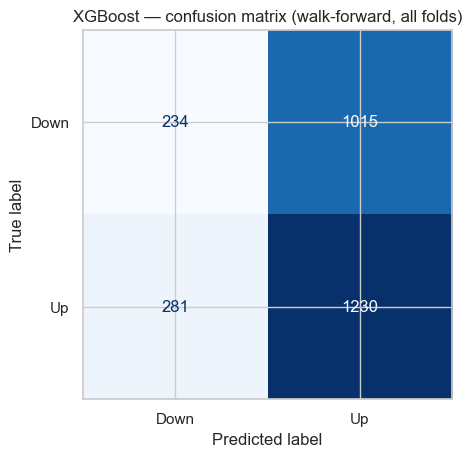

Predicted 'Up' share: 0.813
Actual    'Up' share: 0.547


In [65]:
y_true_all, y_pred_all = [], []
for train_idx, test_idx in tscv.split(X):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
    y_tr_cls = (y_tr > 0).astype(int)
    y_te_cls = (y_te > 0).astype(int)
    m = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42)
    m.fit(X_tr, y_tr_cls)
    y_true_all.extend(y_te_cls.tolist())
    y_pred_all.extend(m.predict(X_te).tolist())

cm = confusion_matrix(y_true_all, y_pred_all)
ConfusionMatrixDisplay(cm, display_labels=["Down", "Up"]).plot(cmap="Blues", colorbar=False)
plt.title("XGBoost — confusion matrix (walk-forward, all folds)")
plt.show()

print("Predicted 'Up' share:", round(sum(y_pred_all) / len(y_pred_all), 3))
print("Actual    'Up' share:", round(sum(y_true_all) / len(y_true_all), 3))

In [66]:
def lgbm_objective(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 50, 400),
        learning_rate=trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
        num_leaves=trial.suggest_int("num_leaves", 4, 64),
        max_depth=trial.suggest_int("max_depth", 2, 6),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        random_state=42,
        verbose=-1,
    )
    diffs = []
    for train_idx, test_idx in tscv.split(X):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
        y_tr_cls = (y_tr > 0).astype(int)
        y_te_cls = (y_te > 0).astype(int)
        m = lgb.LGBMClassifier(**params)
        m.fit(X_tr, y_tr_cls)
        diffs.append(accuracy_score(y_te_cls, m.predict(X_te)) - y_te_cls.mean())
    mean_diff = float(np.mean(diffs))
    with mlflow.start_run(run_name=f"lgbm_trial_{trial.number}", nested=True):
        mlflow.set_tag("model", "lightgbm_optuna")
        mlflow.log_params(params)
        mlflow.log_metric("mean_diff", mean_diff)
    return mean_diff

with mlflow.start_run(run_name="lgbm_optuna_study"):
    study_lgbm = optuna.create_study(direction="maximize")
    study_lgbm.optimize(lgbm_objective, n_trials=30)
    mlflow.log_params(study_lgbm.best_params)
    mlflow.log_metric("best_mean_diff", study_lgbm.best_value)

print("LGBM best mean_diff:", round(study_lgbm.best_value, 4))
print("LGBM best params:", study_lgbm.best_params)

[I 2026-06-18 19:29:17,616] A new study created in memory with name: no-name-0550e9de-064f-429e-94fc-61e4e9e6ae42
[I 2026-06-18 19:29:18,915] Trial 0 finished with value: -0.01666666666666663 and parameters: {'n_estimators': 273, 'learning_rate': 0.013063581584764491, 'num_leaves': 13, 'max_depth': 4, 'subsample': 0.6689650789255477, 'colsample_bytree': 0.6586117396036866}. Best is trial 0 with value: -0.01666666666666663.
[I 2026-06-18 19:29:19,090] Trial 1 finished with value: 0.0 and parameters: {'n_estimators': 73, 'learning_rate': 0.005655597137352002, 'num_leaves': 25, 'max_depth': 2, 'subsample': 0.7386099147213645, 'colsample_bytree': 0.896580958970058}. Best is trial 1 with value: 0.0.
[I 2026-06-18 19:29:19,289] Trial 2 finished with value: -0.002536231884057982 and parameters: {'n_estimators': 50, 'learning_rate': 0.007109125197722886, 'num_leaves': 19, 'max_depth': 3, 'subsample': 0.9803793838983673, 'colsample_bytree': 0.8904227983938191}. Best is trial 1 with value: 0.0.


LGBM best mean_diff: 0.0014
LGBM best params: {'n_estimators': 88, 'learning_rate': 0.008781311385964235, 'num_leaves': 49, 'max_depth': 2, 'subsample': 0.9301318348694707, 'colsample_bytree': 0.73318852130236}


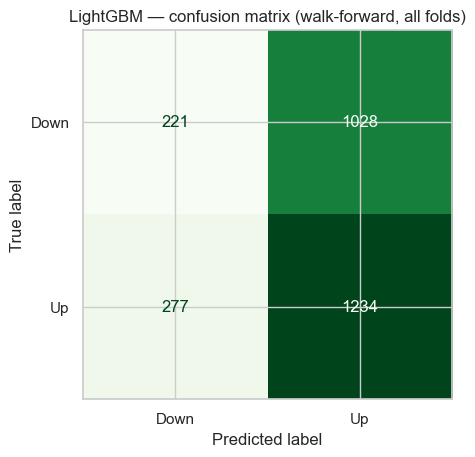

Predicted 'Up' share: 0.82
Actual    'Up' share: 0.547


In [67]:
y_true_all, y_pred_all = [], []
for train_idx, test_idx in tscv.split(X):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
    y_tr_cls = (y_tr > 0).astype(int)
    y_te_cls = (y_te > 0).astype(int)
    m = lgb.LGBMClassifier(n_estimators=100, learning_rate=0.05, num_leaves=8, max_depth=3, random_state=42, verbose=-1)
    m.fit(X_tr, y_tr_cls)
    y_true_all.extend(y_te_cls.tolist())
    y_pred_all.extend(m.predict(X_te).tolist())

cm = confusion_matrix(y_true_all, y_pred_all)
ConfusionMatrixDisplay(cm, display_labels=["Down", "Up"]).plot(cmap="Greens", colorbar=False)
plt.title("LightGBM — confusion matrix (walk-forward, all folds)")
plt.show()

print("Predicted 'Up' share:", round(sum(y_pred_all) / len(y_pred_all), 3))
print("Actual    'Up' share:", round(sum(y_true_all) / len(y_true_all), 3))

In [68]:
y_train_cls = (y_train > 0).astype(int)
y_test_cls = (y_test > 0).astype(int)

model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42)
model.fit(X_train, y_train_cls)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test_cls, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.5309


In [69]:
y_train_cls = (y_train > 0).astype(int)
y_test_cls = (y_test > 0).astype(int)

model = lgb.LGBMClassifier(n_estimators = 100, learning_rate = 0.05, num_leaves = 8, max_depth = 3, random_state = 42, verbose = -1)
model.fit(X_train, y_train_cls)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test_cls, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.5324


In [70]:
baseline_accuracy = y_test_cls.mean()
print(f"Accuracy (always up): {baseline_accuracy:.4f}")

Accuracy (always up): 0.5354


In [71]:
SEQ_LEN = 10 

X_values = X.values  
y_values = y.values

X_seq = []
y_seq = []

for i in range(len(X_values) - SEQ_LEN):
    window_X = X_values[i : i + SEQ_LEN]
    target_y = y_values[i + SEQ_LEN]
    
    X_seq.append(window_X)
    y_seq.append(target_y)

X_seq = np.asarray(X_seq, dtype=np.float32)
y_seq = np.asarray(y_seq, dtype=np.float32)

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq, y_seq, 
    test_size=0.2, 
    shuffle=False 
)

In [72]:
print(X_seq.dtype)

float32


In [73]:
print("before tensor")
X_train_t = torch.tensor(X_train_seq, dtype=torch.float32)
print("after tensor")

before tensor
after tensor


In [74]:
X_train_t = torch.tensor(X_train_seq, dtype=torch.float32)
y_train_t = torch.tensor(y_train_seq, dtype=torch.float32)
X_test_t = torch.tensor(X_test_seq, dtype=torch.float32)
y_test_t = torch.tensor(y_test_seq, dtype=torch.float32)

BATCH_SIZE = 32

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False) 

test_dataset = TensorDataset(X_test_t, y_test_t)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [75]:
class StockTransformer(nn.Module):
    def __init__(self, num_features, seq_len=SEQ_LEN, d_model=64, nhead=4, num_layers=2):
        super(StockTransformer, self).__init__()

        self.input_layer = nn.Linear(num_features, d_model)
        self.pos_embedding = nn.Parameter(torch.zeros(1, seq_len, d_model))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            batch_first=True,
            dim_feedforward=128,
            dropout=0.1
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output_layer = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.input_layer(x)
        x = x + self.pos_embedding
        x = self.transformer_encoder(x)
        x = x[:, -1, :]
        out = self.output_layer(x)
        return out.squeeze()

num_features = X_train_seq.shape[2]
model = StockTransformer(num_features=num_features)
print(model)

StockTransformer(
  (input_layer): Linear(in_features=12, out_features=64, bias=True)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (output_layer): Linear(in_features=64, out_features=1, bias=True)
)


In [76]:
samples_train, seq_len, features = X_train_seq.shape
X_train_2d = X_train_seq.reshape(-1, features)

samples_test, _, _ = X_test_seq.shape
X_test_2d = X_test_seq.reshape(-1, features)

scaler = StandardScaler()
X_train_scaled_2d = scaler.fit_transform(X_train_2d)
X_test_scaled_2d = scaler.transform(X_test_2d)

X_train_seq_scaled = X_train_scaled_2d.reshape(samples_train, seq_len, features)
X_test_seq_scaled = X_test_scaled_2d.reshape(samples_test, seq_len, features)

In [77]:
X_train_t = torch.tensor(X_train_seq_scaled, dtype=torch.float32)
X_test_t = torch.tensor(X_test_seq_scaled, dtype=torch.float32)

y_train_seq_cls = (y_train_seq > 0).astype(np.float32)
y_test_seq_cls = (y_test_seq > 0).astype(np.float32)
y_train_t_cls = torch.tensor(y_train_seq_cls)
y_test_t_cls = torch.tensor(y_test_seq_cls)

train_dataset = TensorDataset(X_train_t, y_train_t_cls)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)

test_dataset = TensorDataset(X_test_t, y_test_t_cls)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

model = StockTransformer(num_features=features)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

EPOCHS = 8

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0
    correct_preds = 0
    total_preds = 0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_X).squeeze()
        targets = batch_y.float().squeeze()
        
        loss = criterion(predictions, targets)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
        predicted_classes = (predictions > 0).float()
        correct_preds += (predicted_classes == targets).sum().item()
        total_preds += targets.size(0)
        
    avg_loss = epoch_loss / len(train_loader)
    epoch_acc = correct_preds / total_preds
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch + 1}/{EPOCHS}] | Accuracy: {epoch_acc:.4f}")

model.eval()
correct_preds_test = 0
total_preds_test = 0

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        predictions = model(batch_X).squeeze()
        targets = batch_y.float().squeeze()
        
        predicted_classes = (predictions > 0).float()
        
        correct_preds_test += (predicted_classes == targets).sum().item()
        total_preds_test += targets.size(0)

test_accuracy = correct_preds_test / total_preds_test

#I dont know how to set seed so the results are not reproducible but im getting 56% roughly, sometimes more sometimes less

print(f"Final Test Accuracy: {test_accuracy:.4f}")

Epoch [1/8] | Accuracy: 0.5361
Epoch [5/8] | Accuracy: 0.5532
Final Test Accuracy: 0.5325


In [78]:
def transformer_objective(trial):
    EPOCHS = 8
    BATCH_SIZE = 32
    lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
    d_model = trial.suggest_categorical("d_model", [32, 64])
    nhead = trial.suggest_categorical("nhead", [2, 4])
    num_layers = trial.suggest_int("num_layers", 1, 3)

    diffs = []
    for train_idx, test_idx in tscv.split(X_all):
        scaler = StandardScaler()
        X_tr_scaled = scaler.fit_transform(X_all[train_idx])
        X_te_scaled = scaler.transform(X_all[test_idx])
        y_tr_raw, y_te_raw = y_all[train_idx], y_all[test_idx]

        def make_seq(Xv, yv):
            Xs, ys = [], []
            for i in range(len(Xv) - SEQ_LEN):
                Xs.append(Xv[i:i+SEQ_LEN]); ys.append(yv[i+SEQ_LEN])
            return np.asarray(Xs, dtype=np.float32), np.asarray(ys, dtype=np.float32)

        X_tr_seq, y_tr_seq = make_seq(X_tr_scaled, y_tr_raw)
        X_te_seq, y_te_seq = make_seq(X_te_scaled, y_te_raw)
        y_tr_cls = (y_tr_seq > 0).astype(np.float32)
        y_te_cls = (y_te_seq > 0).astype(np.float32)

        tr_loader = DataLoader(TensorDataset(
            torch.tensor(X_tr_seq), torch.tensor(y_tr_cls)), batch_size=BATCH_SIZE, shuffle=False)

        model = StockTransformer(num_features=X_tr_seq.shape[2], d_model=d_model, nhead=nhead, num_layers=num_layers)
        criterion = nn.BCEWithLogitsLoss()
        optimizer = optim.Adam(model.parameters(), lr=lr)
        model.train()
        for _ in range(EPOCHS):
            for bx, by in tr_loader:
                optimizer.zero_grad()
                loss = criterion(model(bx).squeeze(), by.float().squeeze())
                loss.backward(); optimizer.step()

        model.eval()
        with torch.no_grad():
            pred_cls = (model(torch.tensor(X_te_seq)).squeeze() > 0).float().numpy()
        diffs.append(accuracy_score(y_te_cls, pred_cls) - y_te_cls.mean())

    mean_diff = float(np.mean(diffs))
    with mlflow.start_run(run_name=f"transformer_trial_{trial.number}", nested=True):
        mlflow.set_tag("model", "transformer_optuna")
        mlflow.log_params(dict(lr=lr, d_model=d_model, nhead=nhead, num_layers=num_layers, epochs=EPOCHS))
        mlflow.log_metric("mean_diff", mean_diff)
    return mean_diff

with mlflow.start_run(run_name="transformer_optuna_study"):
    study_tf = optuna.create_study(direction="maximize")
    study_tf.optimize(transformer_objective, n_trials=10)
    mlflow.log_params(study_tf.best_params)
    mlflow.log_metric("best_mean_diff", study_tf.best_value)

print("Transformer best mean_diff:", round(study_tf.best_value, 4))
print("Transformer best params:", study_tf.best_params)

[I 2026-06-18 19:29:36,854] A new study created in memory with name: no-name-f3608f57-014a-44a5-8892-66ffb0a3e81f
[I 2026-06-18 19:29:40,046] Trial 0 finished with value: -0.03357933089137077 and parameters: {'lr': 0.001415374104333306, 'd_model': 64, 'nhead': 2, 'num_layers': 1}. Best is trial 0 with value: -0.03357933089137077.
[I 2026-06-18 19:29:42,756] Trial 1 finished with value: -0.01291513442993164 and parameters: {'lr': 0.00037655096237346663, 'd_model': 32, 'nhead': 2, 'num_layers': 1}. Best is trial 1 with value: -0.01291513442993164.
[I 2026-06-18 19:29:51,989] Trial 2 finished with value: -0.0099630830809474 and parameters: {'lr': 0.00013907405478535333, 'd_model': 32, 'nhead': 4, 'num_layers': 3}. Best is trial 2 with value: -0.0099630830809474.
[I 2026-06-18 19:29:57,943] Trial 3 finished with value: -0.015867162495851517 and parameters: {'lr': 0.0024589529534673193, 'd_model': 64, 'nhead': 2, 'num_layers': 2}. Best is trial 2 with value: -0.0099630830809474.
[I 2026-06-

Transformer best mean_diff: -0.01
Transformer best params: {'lr': 0.00013907405478535333, 'd_model': 32, 'nhead': 4, 'num_layers': 3}


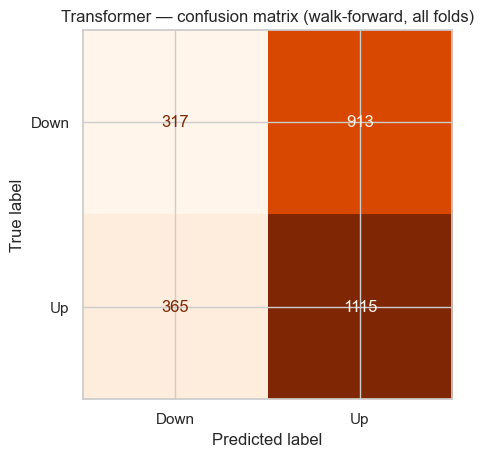

Predicted 'Up' share: 0.748
Actual    'Up' share: 0.546


In [79]:
y_true_all, y_pred_all = [], []
for train_idx, test_idx in tscv.split(X_all):
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_all[train_idx])
    X_te_scaled = scaler.transform(X_all[test_idx])
    y_tr_raw, y_te_raw = y_all[train_idx], y_all[test_idx]

    def make_seq(Xv, yv):
        Xs, ys = [], []
        for i in range(len(Xv) - SEQ_LEN):
            Xs.append(Xv[i:i+SEQ_LEN]); ys.append(yv[i+SEQ_LEN])
        return np.asarray(Xs, dtype=np.float32), np.asarray(ys, dtype=np.float32)

    X_tr_seq, y_tr_seq = make_seq(X_tr_scaled, y_tr_raw)
    X_te_seq, y_te_seq = make_seq(X_te_scaled, y_te_raw)
    y_tr_cls = (y_tr_seq > 0).astype(np.float32)
    y_te_cls = (y_te_seq > 0).astype(np.float32)

    tr_loader = DataLoader(TensorDataset(
        torch.tensor(X_tr_seq), torch.tensor(y_tr_cls)), batch_size=32, shuffle=False)

    model = StockTransformer(num_features=X_tr_seq.shape[2])
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0001)
    model.train()
    for _ in range(15):
        for bx, by in tr_loader:
            optimizer.zero_grad()
            loss = criterion(model(bx).squeeze(), by.float().squeeze())
            loss.backward(); optimizer.step()

    model.eval()
    with torch.no_grad():
        pred_cls = (model(torch.tensor(X_te_seq)).squeeze() > 0).float().numpy()

    y_true_all.extend(y_te_cls.tolist())
    y_pred_all.extend(pred_cls.tolist())

cm = confusion_matrix(y_true_all, y_pred_all)
ConfusionMatrixDisplay(cm, display_labels=["Down", "Up"]).plot(cmap="Oranges", colorbar=False)
plt.title("Transformer — confusion matrix (walk-forward, all folds)")
plt.show()

print("Predicted 'Up' share:", round(sum(y_pred_all) / len(y_pred_all), 3))
print("Actual    'Up' share:", round(sum(y_true_all) / len(y_true_all), 3))